**Valor aportado al negocio**

Somos DataFuel, una consultora especializada en el análisis de datos orientado a la toma de decisiones estratégicas. Nos enfocamos en transformar grandes volúmenes de información a un formato mucho más claro facilitando la toma de acciones que impulsen a la eficiencia operativa y rentabilidad de nuestro clientes.

**Contexto**

La empresa radio taxi “Premium” se encuentra en un proceso de renovación de su propia flota, proyectado a diez años. Actualmente, sus vehículos funcionan con diferentes tipos de combustible, y el gasto en combustible representa uno de sus principales costos operativos.
Por lo tanto, nos solicitó asistencia tanto como para planear esta renovación como para optimizar su estrategia de abastecimiento de combustible para poder reducir el costo operativo de la empresa.
La propuesta se enfocará en un análisis integral de los datos disponibles en el dataset donde se investiguen los siguientes puntos.
Identificación de estaciones de servicio con precios más económicos, dentro de su zona de operación.
Identificar el tipo de combustible a priorizar en los vehículos de la nueva flota, basándose en los costos.

**Hipotesis**


1.   A través del análisis histórico de precios por tipo de combustible (nafta, diésel, GNC) se podrá identificar cuál conviene priorizar para la nueva flota.
2.   La identificación de estaciones de servicio con mejores precios permitirá reducir costos operativos en el corto plazo.
1.   Una proyección de precios permitirá anticiparse a aumentos y ajustar presupuestos anuales.

**Valor Aportado**


*   Desde el punto de vista de la visualizacion, esto nos va a permitir tener un dashboard con evolucion de precios, comparacion por tipo de combustible y esto nos permitira tomar decisiones más rapidamente.
*   Mediante el procesamiento de Machine Learning vamos a obtener un modelo de predicción de precios futuros, que nos facilitara el proceso de planificacion de elección de flota.
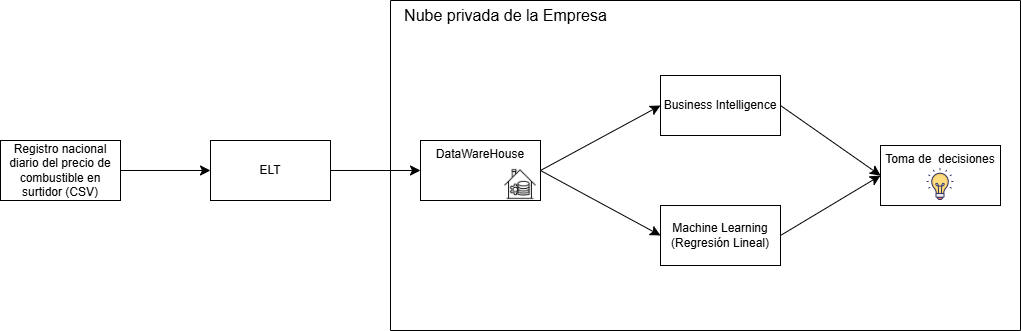

In [ ]:
# Análisis de precios de combustibles - DataFuel
# Dataset: http://datos.energia.gob.ar/dataset/1c181390-5045-475e-94dc-410429be4b17/archivo/80ac25de-a44a-4445-9215-090cf55cfda5

In [ ]:
# Secciones:
# 4. Limpieza de datos
# 5. Evaluación de calidad de datos
# 6. Análisis Exploratorio (EDA)
# 7. Predicción de precios (ML con Scikit-Learn)

In [ ]:
!pip install pandas scikit-learn matplotlib seaborn --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# Configuración
plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option('display.max_columns', None)

In [ ]:
# Carga del dataset


df = pd.read_csv("/content/precios-en-surtidor-resolucin-3142016.csv", sep=',', encoding='utf-8')
df.head()

,indice_tiempo,idempresa,cuit,empresa,direccion,localidad,provincia,region,idproducto,producto,idtipohorario,tipohorario,precio,fecha_vigencia,idempresabandera,empresabandera,latitud,longitud,geojson
0,2025-06,1376,33-64337382-9,10 DE SETIEMBRE S.A.,Av. Mosconi 299,LOMAS DEL MIRADOR,BUENOS AIRES,PAMPEANA,19,Gas Oil Grado 2,2,Diurno,1237.0,2025-06-03 09:01:00,28,PUMA,-34.658476,-58.529443,"{""type"":""Point"",""coordinates"":[-58.529443,-34...."
1,2025-06,1376,33-64337382-9,10 DE SETIEMBRE S.A.,Av. Mosconi 299,LOMAS DEL MIRADOR,BUENOS AIRES,PAMPEANA,19,Gas Oil Grado 2,3,Nocturno,1237.0,2025-06-03 09:01:00,28,PUMA,-34.658476,-58.529443,"{""type"":""Point"",""coordinates"":[-58.529443,-34...."
2,2025-06,1376,33-64337382-9,10 DE SETIEMBRE S.A.,Av. Mosconi 299,LOMAS DEL MIRADOR,BUENOS AIRES,PAMPEANA,21,Gas Oil Grado 3,2,Diurno,1464.0,2025-06-03 09:01:00,28,PUMA,-34.658476,-58.529443,"{""type"":""Point"",""coordinates"":[-58.529443,-34...."
3,2025-06,1376,33-64337382-9,10 DE SETIEMBRE S.A.,Av. Mosconi 299,LOMAS DEL MIRADOR,BUENOS AIRES,PAMPEANA,21,Gas Oil Grado 3,3,Nocturno,1464.0,2025-06-03 09:01:00,28,PUMA,-34.658476,-58.529443,"{""type"":""Point"",""coordinates"":[-58.529443,-34...."
4,2025-05,1376,33-64337382-9,10 DE SETIEMBRE S.A.,Av. Mosconi 299,LOMAS DEL MIRADOR,BUENOS AIRES,PAMPEANA,6,GNC,2,Diurno,499.9,2025-05-30 12:05:00,28,PUMA,-34.658476,-58.529443,"{""type"":""Point"",""coordinates"":[-58.529443,-34...."


In [ ]:
print(df['region'].unique())     # Para ver si BUENOS AIRES está ahí
print(df['provincia'].unique())  # Para confirmar si está ahí

['PAMPEANA' nan 'PATAGONIA' 'CUYO' 'CENTRO' 'NEA' 'NOA']
['BUENOS AIRES' 'RIO NEGRO' 'CHUBUT' 'SAN LUIS' 'SANTA FE' 'ENTRE RIOS'
 'CHACO' 'SANTIAGO DEL ESTERO' 'MENDOZA' 'CATAMARCA' 'CORDOBA' 'SALTA'
 'MISIONES' 'TUCUMAN' 'CORRIENTES' 'LA PAMPA' 'CAPITAL FEDERAL'
 'SANTA CRUZ' 'NEUQUEN' 'JUJUY' 'FORMOSA' 'SAN JUAN' 'LA RIOJA'
 'TIERRA DEL FUEGO']


**Limpieza del dataset**


---


**Transformaciones realizadas**

1.   **Filtrado por provincia: Buenos aires**: Elegimos esto ya que se trata del area de operacion de la empresa.
1.   **Eliminacion de registros con campos nulos en "Region"**: Esta transformación nos permitio eliminar filas sin datos y asi evitar posibles errores que puedan surgir en las proximas etapas del trabajo.
2.   **Eliminacion de columnas irrelevantes:(idhorario, tipohorario, indice_tiempo, geojson)**: Se decidio eliminar estas columnas ya que no aportan valor al análisis ni al tablero, en el contexto establecido en el trabajo debido a que la información que aportan termina siendo redundante.
2.   **Eliminacion de duplicados**: Decidimos eliminarlos porque datos repetidos distorsionan los promedios y análisis temporales.
1.   **Normalización de 'empresa', 'producto', 'empresabandera', 'localidad', 'provincia', 'region'(usando pipeline de Sklearn)**: Realizamos esta normalizacion para Evitar que las columnas seleccionadas  con variaciones de escritura aparezcan como distintas.






In [ ]:
# Limpieza
#1
df = df[df['provincia'].str.contains("BUENOS AIRES", na=False)]
#2
df = df.dropna(subset=['region'])
#3
columnas_a_eliminar = ['idhorario', 'tipohorario', 'indice_tiempo', 'geojson']
df = df.drop(columns=[c for c in columnas_a_eliminar if c in df.columns])
#4
df = df.drop_duplicates()

In [ ]:
#5 Normalización de texto
class NormalizeText(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.str.lower().str.strip()

In [ ]:
# Columnas que querés normalizar (pueden ajustarse según tu dataset)
columns_to_normalize = ['empresa', 'producto', 'empresabandera', 'localidad', 'provincia', 'region']

# Instancia del pipeline
pipeline = Pipeline([('normalize', NormalizeText())])

# Aplicar normalización a cada columna seleccionada
for col in columns_to_normalize:
    if col in df.columns:
        df[col] = pipeline.fit_transform(df[col])

In [ ]:
# Conversión de tipos
df['fecha_vigencia'] = pd.to_datetime(df['fecha_vigencia'])
df['precio'] = pd.to_numeric(df['precio'], errors='coerce')
df = df.dropna(subset=['precio'])
df['region'] = df['region'].astype('category')

**Evaluación de la calidad de los datos**


---


**Métricas propuestas:**

**Porcentaje de valores faltantes por columna**


*   **Justificación:** Nos permite identificar cuáles columnas no nos serán útiles para los análisis a realizar (datos inútiles, nulos, inconsistentes e irrelevantes).  


*   **Umbral aceptable:** Se tomará un umbral <5%, debido a que así se asegurará la menor cantidad de información perdida, una mayor estabilidad en la distribución y no se necesitará de rellenar valores faltantes a través de ML.


**Número de registros duplicados:**


*   **Justificación:** Evita que sucedan sesgos en nuestros cálculos como consecuencia de la existencia de datos redundantes.


*   **Umbral aceptable:**Se toma un umbral del 0% de registros duplicados, para evitar inflaciones de valores como conteos, totales y frecuencias o tendencias.

In [ ]:
# Evaluación de calidad
missing_percent = df.isnull().mean() * 100
print("Porcentaje de valores faltantes:\n", missing_percent)
duplicates = df.duplicated().sum()
print("\nCantidad de duplicados:", duplicates)
print("\nCategorías únicas en producto:\n", df['producto'].unique())

Porcentaje de valores faltantes:
 idempresa           0.0
cuit                0.0
empresa             0.0
direccion           0.0
localidad           0.0
provincia           0.0
region              0.0
idproducto          0.0
producto            0.0
idtipohorario       0.0
precio              0.0
fecha_vigencia      0.0
idempresabandera    0.0
empresabandera      0.0
latitud             0.0
longitud            0.0
dtype: float64

Cantidad de duplicados: 0

Categorías únicas en producto:
 ['gas oil grado 2' 'gas oil grado 3' 'gnc'
 'nafta (premium) de más de 95 ron' 'nafta (súper) entre 92 y 95 ron']


**Reporte de Calidad**

Como se puede ver en los resultados de la evaluación de calidad, tras la limpieza realizada inicialmente, no quedaron registros con valores nulas y se eliminaron en su totalidad los registros duplicados.

**Análisis exploratorio (EDA)**


---


**Visualizaciones propuestas:**
*   Evolución temporal del precio por tipo de combustible


*   Comparación promedio de precios por tipo de combustible


*   Mapa de calor o scatter geo de precios por estación (dentro de CABA/GBA)


**Estadísticas de interés:**
*   Promedios, máximos y mínimos por tipo de combustible


*   Volatilidad (std) mensual del precio.


*   Tendencia temporal de precios


In [ ]:
# EDA
df['año'] = df['fecha_vigencia'].dt.year
df['mes'] = df['fecha_vigencia'].dt.month

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Asegurate de tener el dataframe principal cargado como "df"
# Convertir 'fecha_vigencia' en datetime si aún no está bien convertido
df['fecha_vigencia'] = pd.to_datetime(df['fecha_vigencia'], errors='coerce')

# Verificamos si hay valores nulos en las columnas clave
print(df[['fecha_vigencia', 'precio', 'producto']].isna().sum())

# Crear nuevo dataframe solo con las columnas necesarias y sin nulos
df_plot = df[['fecha_vigencia', 'precio', 'producto']].dropna()
print(f"Filas disponibles para graficar: {len(df_plot)}")

fecha_vigencia    0
precio            0
producto          0
dtype: int64
Filas disponibles para graficar: 10995


In [ ]:
print("Cantidad de filas total del dataframe:", len(df))
print("Cantidad de filas con producto, precio y fecha_vigencia válidos:",
      df[['fecha_vigencia', 'precio', 'producto']].dropna().shape[0])

Cantidad de filas total del dataframe: 10995
Cantidad de filas con producto, precio y fecha_vigencia válidos: 10995


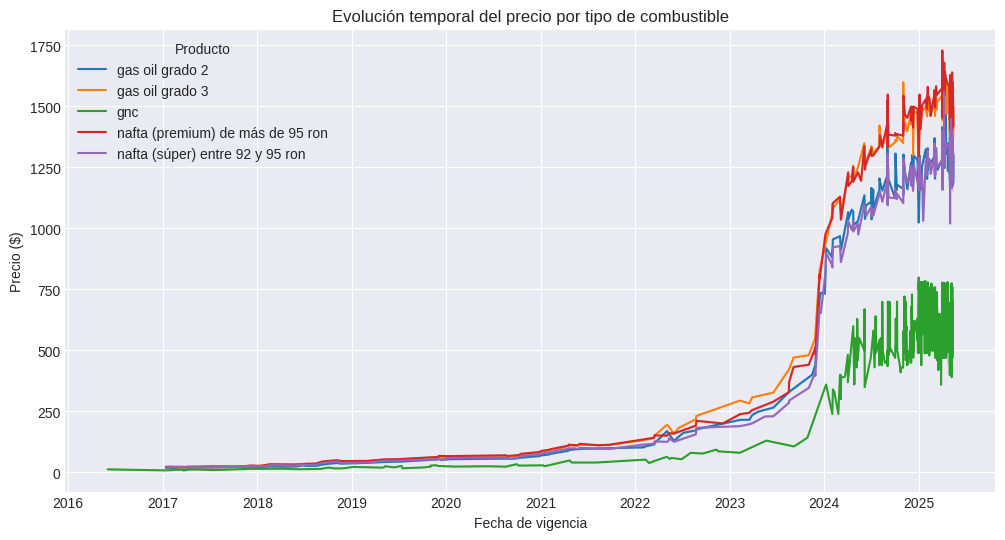

In [ ]:
if not df_plot.empty:
    plt.figure(figsize=(12,6))
    sns.lineplot(data=df_plot, x='fecha_vigencia', y='precio', hue='producto')
    plt.title("Evolución temporal del precio por tipo de combustible")
    plt.xlabel("Fecha de vigencia")
    plt.ylabel("Precio ($)")
    plt.legend(title='Producto')
    plt.show()
else:
    print("No hay datos válidos para graficar. Revisá los valores nulos o el formato de las fechas.")

Esta grafica nos permite visualizar como el valor del combustible, segun su tipo, fue fluctuando en el paso del tiempo

<ipython-input-16-dfaf868bbe2a>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='producto', y='precio', estimator=np.mean, ci=None)


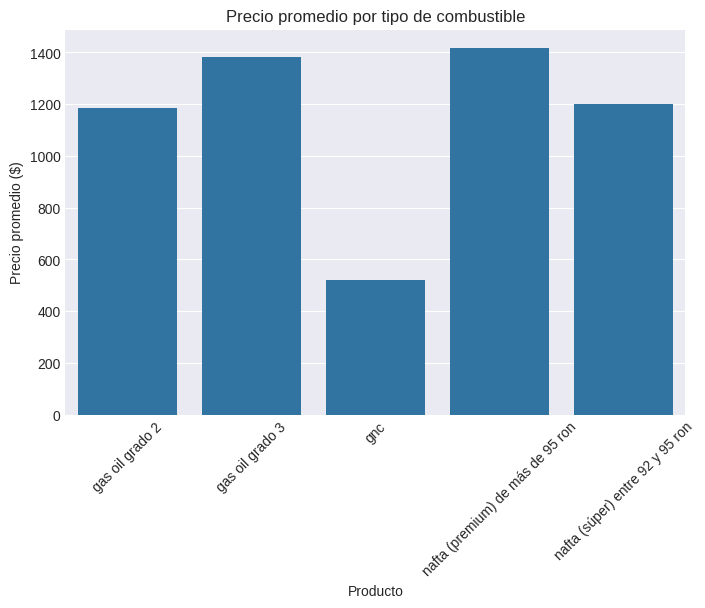

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='producto', y='precio', estimator=np.mean, ci=None)
plt.title("Precio promedio por tipo de combustible")
plt.ylabel("Precio promedio ($)")
plt.xlabel("Producto")
plt.xticks(rotation=45)
plt.show()

Con esta grafica, podemos comparar facilmente los precios de los distintos productos.

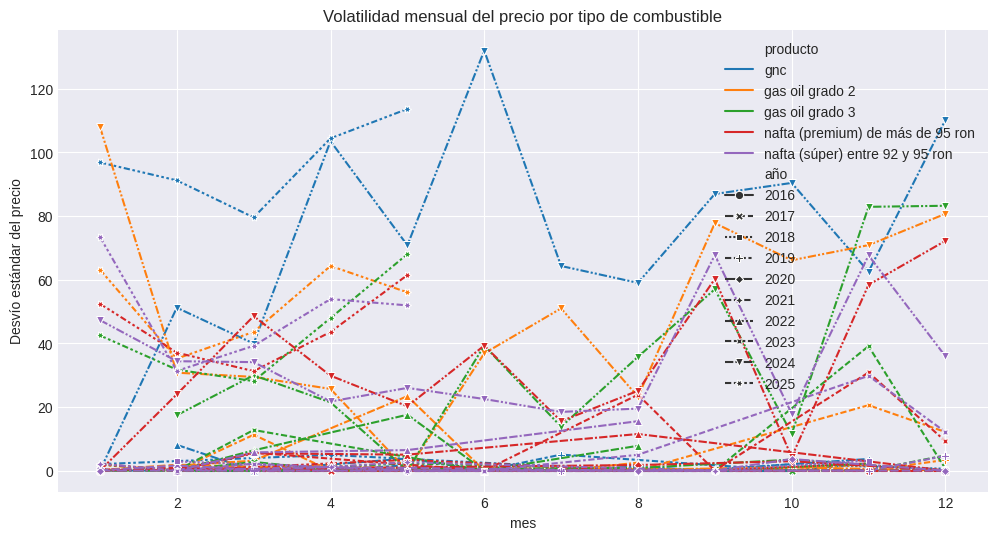

In [ ]:
std_mensual = df.groupby(['año', 'mes', 'producto'])['precio'].std().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=std_mensual, x='mes', y='precio', hue='producto', style='año', markers=True)
plt.title("Volatilidad mensual del precio por tipo de combustible")
plt.ylabel("Desvío estándar del precio")
plt.show()

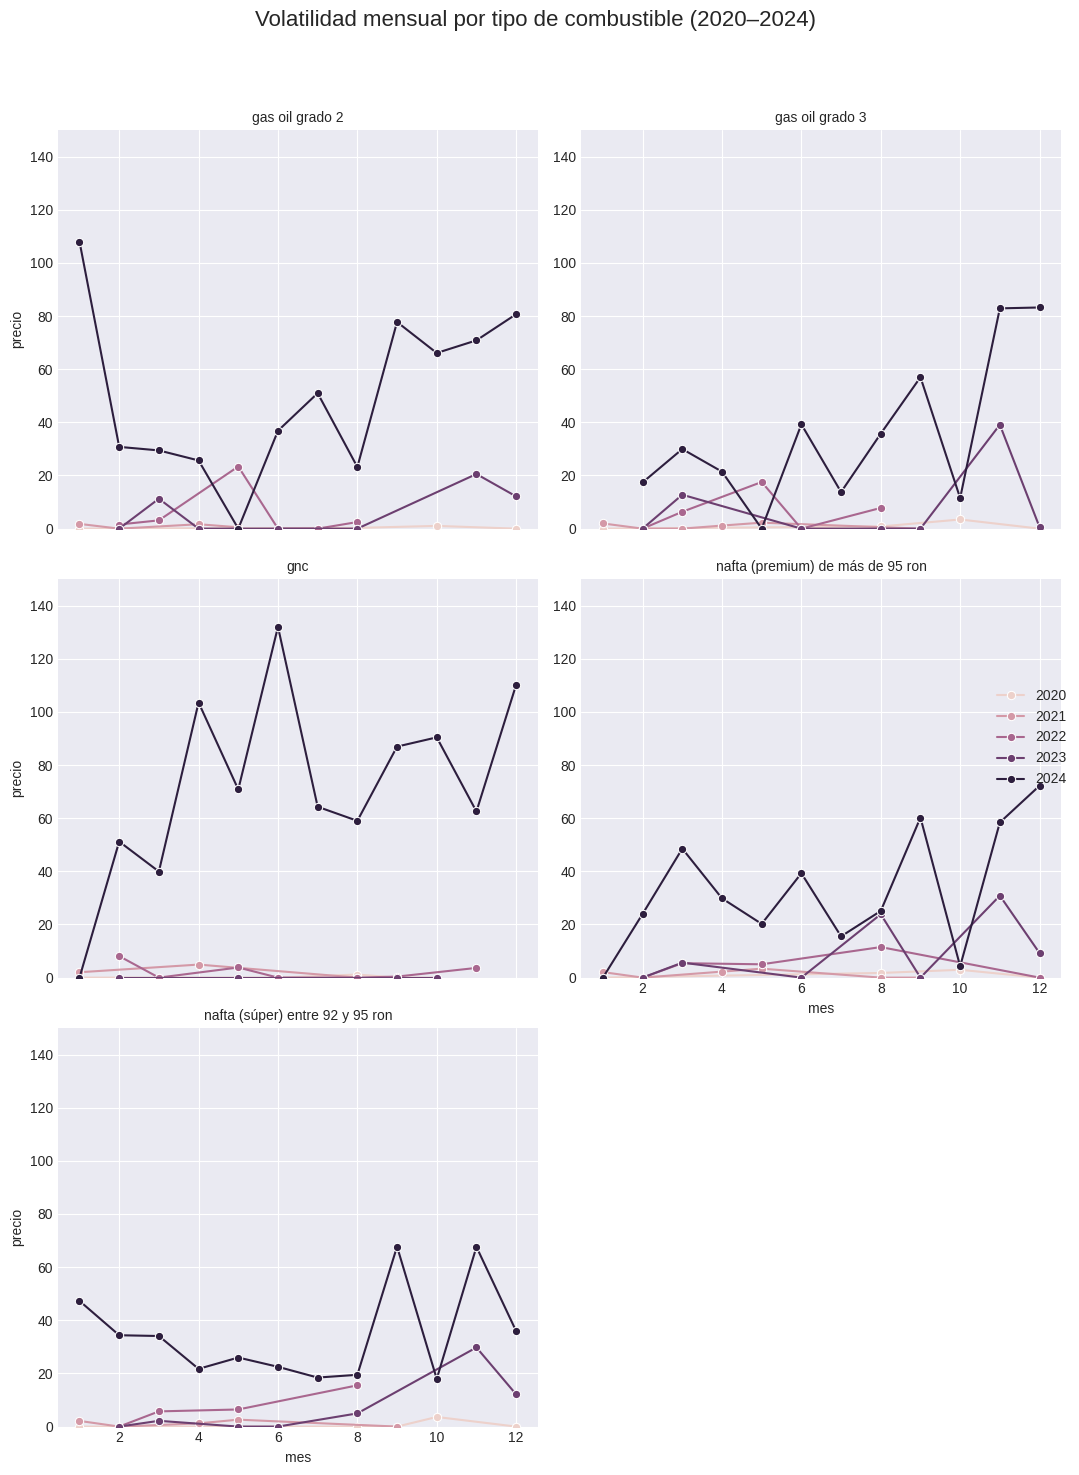

In [ ]:
std_mensual_filtrado = std_mensual[(std_mensual['año'] >= 2020) & (std_mensual['año'] <= 2024)]
g = sns.FacetGrid(std_mensual_filtrado, col="producto", col_wrap=2, height=5, sharey=False)
g.map_dataframe(sns.lineplot, x='mes', y='precio', hue='año', marker='o')
g.set(ylim=(0, 150))
g.set_titles(col_template="{col_name}")
g.add_legend()
g.fig.suptitle("Volatilidad mensual por tipo de combustible (2020–2024)", fontsize=16)
g.fig.tight_layout()
g.fig.subplots_adjust(top=0.9)  # para que no se superponga el título

plt.show()

Estas graficas muestran la volatilidad del combustible y para que sea mas facil de visualizar, la dividimos en graficas distintas para cada tipo de combustible.

**Reporte EDA**

Al realizar este analisis exploratorio, pudimos llegar a las siguientes conclusiones:


1.   La Nafta tiene tendencia a subir de precio, pero tiene baja volatilidad.
2.   El GNC muestra mayor variabilidad de precios.
2.   El Diesel premium suele tener los precios más elevados en promedio,



**Predicción de precios con Scikit-Learn**


---


**Objetivo:**
Predecir el precio del combustible en base a la fecha y al tipo de combustible.

Se eligió el modelo de Regresión Lineal, debido a que ofrece una solución simple, eficiente y fácilmente interpretable para predecir la evolución de precios de combustibles en función del tiempo y del tipo de producto. Además, el modelo se ajusta bien a la naturaleza del dataset, donde se espera una relación progresiva entre la fecha y el precio.


In [ ]:
# Exportar dataset limpio
df.to_csv("combustibles_limpio.csv", index=False)
print("Archivo exportado: combustibles_limpio.csv")

Archivo exportado: combustibles_limpio.csv


In [ ]:
# ML: predicción de precios
df_modelo = df.copy()
df_modelo['fecha_ordinal'] = df_modelo['fecha_vigencia'].map(pd.Timestamp.toordinal)
X = df_modelo[['fecha_ordinal', 'producto']]
y = df_modelo['precio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
preprocesador = ColumnTransformer(
    transformers=[('producto_encoder', OneHotEncoder(handle_unknown='ignore'), ['producto'])],
    remainder='passthrough'
)

In [ ]:
modelo = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('regresion', LinearRegression())
])

In [ ]:
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Al comparar el precio con el MAE, me da un porcentaje de error de: {((mae*100)/df['precio'].mean()):.2f}%")

MAE: 84.70
RMSE: 145.90
Al comparar el precio con el MAE, me da un porcentaje de error de: 7.06%


Al no tratarse de un contexto critico, consideramos que un error menor al 10% es adecuado.

In [ ]:
# Predicción futura
fecha_futura = pd.to_datetime("2026-01-01").toordinal()
nuevo = pd.DataFrame({'fecha_ordinal': [fecha_futura], 'producto': ['nafta súper']})
prediccion_futura = modelo.predict(nuevo)
print(f"Precio estimado para Nafta Súper en enero 2026: ${prediccion_futura[0]:.2f}")

Precio estimado para Nafta Súper en enero 2026: $1341.33


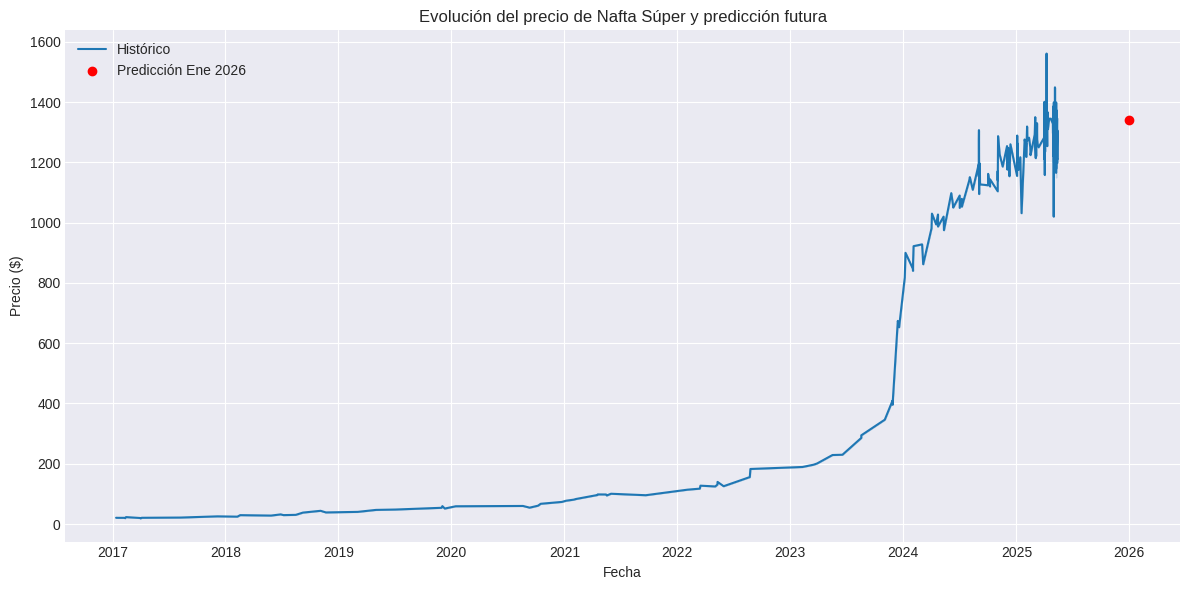

In [ ]:
df['fecha_ordinal'] = df['fecha_vigencia'].map(pd.Timestamp.toordinal)
df_nafta = df[df['idproducto'].isin([2])]
df_nafta = df_nafta.sort_values(by='fecha_vigencia')
fecha_pred = pd.to_datetime("2026-01-01")
precio_pred = prediccion_futura[0]
plt.figure(figsize=(12,6))
sns.lineplot(data=df_nafta, x='fecha_vigencia', y='precio', label='Histórico')
plt.scatter(fecha_pred, precio_pred, color='red', label='Predicción Ene 2026', zorder=5)
plt.title("Evolución del precio de Nafta Súper y predicción futura")
plt.xlabel("Fecha")
plt.ylabel("Precio ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Tablero de Comando**
[Tablero de Comando - Looker](https://lookerstudio.google.com/u/0/reporting/20e0af9b-8de4-46c0-9dc9-147a5464c6e6/page/5WvMF)

**Filtros**
Para nuestro tablero definimos tres tipos de filtros:

*   Temporal: Para poder definir el periodo de tiempo en el que queremos hacer el analisis.
*   Geografico: Para poder delimitar el dataset al area de trabajo de la empresa.
*   Producto: Para poder elegir el tipo de producto a evaluar.

**Graficos**

Tambien realizamos tres graficos distintos
*   Comparativa de precios por estacion de servicio: Este grafico nos va a permitir identificar las estaciones de servicio mas economicas en el area donde trabaja la empresa. Aplicandole los filtros se puede evaluar para cada tipo de producto.
*   Evolución temporal del precio por tipo de combustible: Con este grafico vamos a poder ver facilmente que productos han tenido mayores subidas de precio a lo largo del tiempo.
*   Análisis comparativo de tipos de combustible: Este grafico nos muestra el precio promedio y desviacion estandar de cada producto. Que nos permitira entender facilmente la variabilidad/volatilidad del producto.


**Conclusiones**

Al finalizar este trabajo, analizando la informacion obtenida, pudimos llegar a las siguientes conclusiones:


*   A pesar de su alta volatilidad, debido a su bajo precio, decidimos recomendar como solución utilizar vehiculos equipados con GNC. Entonces, la recomendacion seria buscar renovar la flota con vehiculos, poco usados y en buen estado, equipados con GNC.
*   Con el analisis pudimos confirmar que en la zona de operaciones de la empresa no hay grandes diferencias en los precios ofrecidos por las estaciones de servicio. Por lo tanto, no hay una recomendacion especifica acerca de a cuales estaciones de servicio acudir.

**Trabajo Futuro**

Con el trabajo realizado en este analisis, si en el futuro la empresa decide expandir su area de operaciones a otras regiones, podremos reutilizar este analisis para guiarlos en ese proceso de expansión.
